# Tutorial: Confidence Regions Construction + Drawing

A notebook detailing how to construct and visualize confidence tubes, as well as assess coverage.

Jimmy Butler

In [84]:
library(mvtnorm)
library(ggplot2)
library(ismev)

source('~/michael/isolines_uq/scripts/R/confidence_regions/modules/distributionIsolines.R')
source('~/michael/isolines_uq/scripts/R/confidence_regions/modules/confidenceRegions.R')
source('~/michael/isolines_uq/scripts/R/confidence_regions/modules/coverageEvaluation.R')
source('~/michael/isolines_uq/scripts/R/confidence_regions/modules/visualizeTubes.R')

source('~/michael/isolines_uq/scripts/R/confidence_regions/modules/utils.R')

set.seed(123456)

### Data

Jimmy:
+ Are there repeated observations in the dataset?

In [85]:
hurs_dat <- read.csv('/global/cfs/cdirs/m3318/HadISD/v342_202508p/cities/Philadelphia/Philly.csv')
dat <- data.frame(X1 = hurs_dat$X1, X2 = 1 / hurs_dat$X2 )

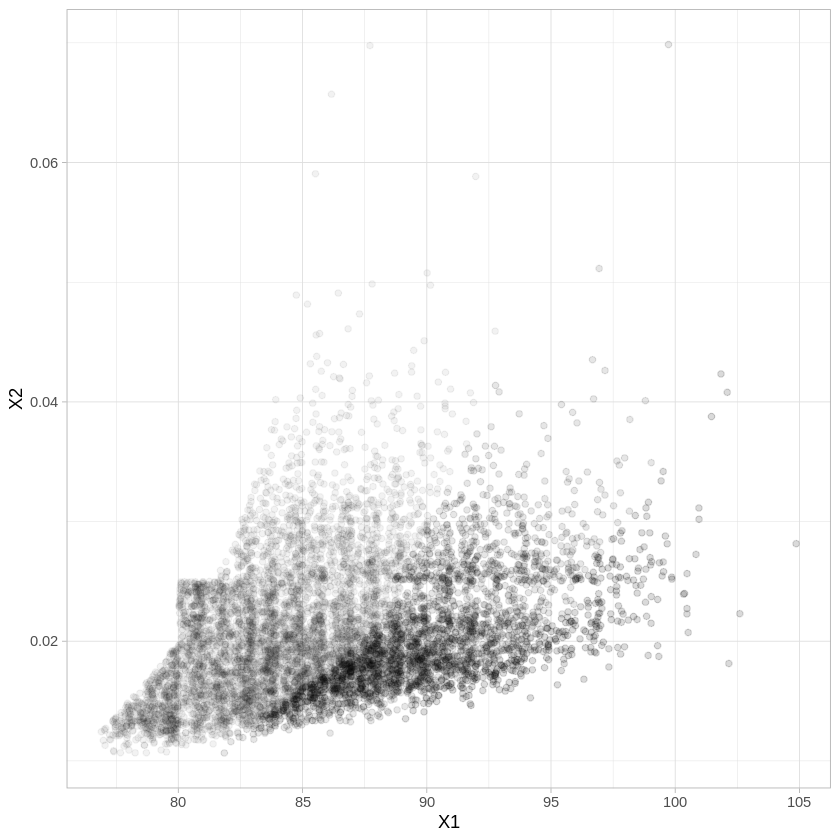

In [86]:
plt1 <- ggplot() + geom_point(data=dat, aes(x=X1, y=X2), alpha=0.05) + theme_light()
plt1

### Constructing a Confidence Tube

#### Non-Extreme Isolines

Let's first construct a confidence tube for the non-extreme isoline. Use the `computeEmpiricalRegion` function in the `confidenceRegions.R` module script. 

Here, I am setting only one `alpha`, and it will be $0.05$, so I am constructing a $95\%$ confidence tube. `B` indicates how many boostrap replicates will be used to estimate the worst case difference between the estimated and true survival functions. `lbs` indicates the lower left corner of our space, since some probability distributions have infinite support and we need to cut it off somewhere. `verbose` prints out a progress bar in case it's helpful, defaults to false.

In [87]:
region <- computeEmpiricalRegion(dat=dat,
                                 alphas=c(0.05),
                                 p=0.05,
                                 B=500,
                                 lbs=c(75,0.01),
                                 verbose=TRUE)

  |======================================================================| 100%


This gives us an estimate of $c$, where $c$ is the $1-\alpha$ quantile of $\sup_{x \in \ell_{\pmb{X}}(q)} |\hat{\bar{F}}(x) - p|$, where $\ell_{\pmb{X}}(q)$ is the distribution's true $q$-isoline, $\hat{\bar{F}}(x)$ is the empirical survival function, and $\bar{F}(x)$ is the underlying distribution's true survival function. Call this estimate $\hat{c}$. The empirical confidence tube is defined as the set of all points in the 2D plane which satisfy the following condition:

\begin{align}
|\hat{\bar{F}}(x) - p| \leq \hat{c}
\end{align}

To visualize this tube, we can simply compute the boundary curves and plot that. Note that if `drawn_tubes$tube_upper` is `NA`, then the tube has no upper bounding curve, only a lower one.

In [97]:
drawn_tubes <- drawEmpiricalTubes(region, alpha=0.05, lbs=c(75,0.01), n_coords=200)
best_estimate <- drawEmpiricalIsoline(dat, n_coords=200, grid_lbs=c(75,0.01), p=0.05)

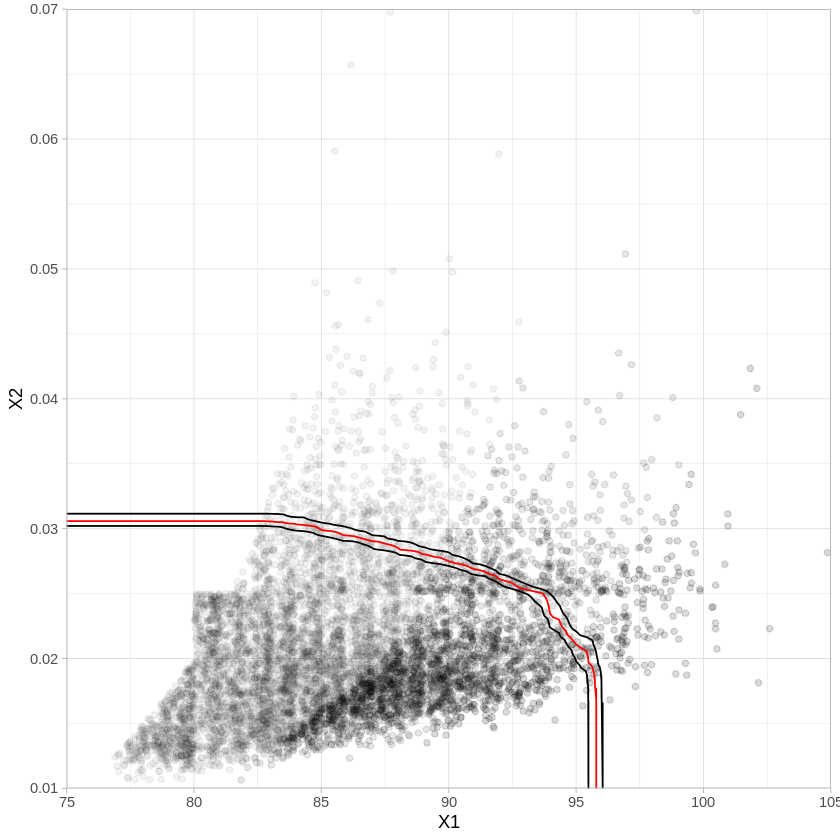

In [99]:
ggplot() + geom_point(data=dat, aes(x=X1, y=X2), alpha=0.05) + 
           geom_line(data=drawn_tubes$tube_lower, aes(x=X1, y=X2)) + 
           geom_line(data=drawn_tubes$tube_upper, aes(x=X1, y=X2)) +
           geom_line(data=best_estimate, aes(x=X1, y=X2), color='red') +
           scale_x_continuous(expand=c(0,0), limits=c(75,105)) +
           scale_y_continuous(expand=c(0,0), limits=c(0.01,.07)) +
           theme_light()

Visually, it seems the tube covers the true isoline. We can check this by verifying each point on the true $q$-isoline satisfies the above conditions of being in the tube. This can be accomplished by the `evaluateCoverage` function in the `coverageEvaluation.R` script. 

Our 95\% confidence tube successfully covers its true isoline.

#### Extreme Isolines

Constructing a tube for the extreme isoline requires a few steps.

1. Convert marginal distribution of data to be approximately pareto-distributed with shape parameter as $1$. (Marginal transformation also takes place in Cooley et al. 2019)
2. Apply `computeExtremeRegion` to this transformed data.
3. Draw the tube, and inverse transform the marginals of the tube.

In addition to the parameters for the non-extreme isolines, we will also need `gamma` and `xi`. `xi` is simply the extreme value index, or the reciprocal of the index of regular variation. We convert our marginal distributions to be pareto with shape parameter $1$, which means after transformation we take $\xi=1$. 

For `gamma`, our procedure uses a blended survival function, in the sense that, for non-extreme or rare probabilities, we use the empirical survival function, and for extreme probabilities, we use extreme value theory. How extreme an observation is depends on how many observations there are: our threshold between extreme and non-extreme probabilities is $n^{-\gamma}$.

In [102]:
gamma <- 1/2
extreme_tube <- computeExtremeRegion(dat=dat,
                                     alphas=c(0.05),
                                     p=0.005,
                                     B=500,
                                     gamma=gamma,
                                     xi=1,
                                     verbose=TRUE)




  |===                                                                   |   5%

In [107]:
transformed_dat <- data.frame(X1=extreme_tube$transform_func1(dat[,1]),
                              X2=extreme_tube$transform_func2(dat[,2]))
best_estimate_transformed <- drawExtremeIsoline(transformed_dat, p=0.005, n_coords=200, grid_lbs=c(0,0), gamma=gamma, xi=1)
best_estimate_original <- data.frame(X1=extreme_tube$inv_transform_func1(best_estimate_transformed[,1]),
                                     X2=extreme_tube$inv_transform_func2(best_estimate_transformed[,2]))

To evaluate coverage of an isoline, we must set the `extreme` flag to true. This tells the function that our tubes were constructed in a transformed space, and that to evaluate coverage, we must transform the isoline first.

To visualize the tubes (in the original, non-transformed space), we use the `drawExtremeTubes` function. Note: if `tube_upper` is `NA`, then this means that the computed tube has no upper bounding curve, only a lower bounding curve.

In [95]:
drawn_tubes <- drawExtremeTubes(extreme_tube, alpha=0.05, n_coords=200)
ext_upper <- drawn_tubes$tube_lower
ext_lower <- drawn_tubes$tube_upper

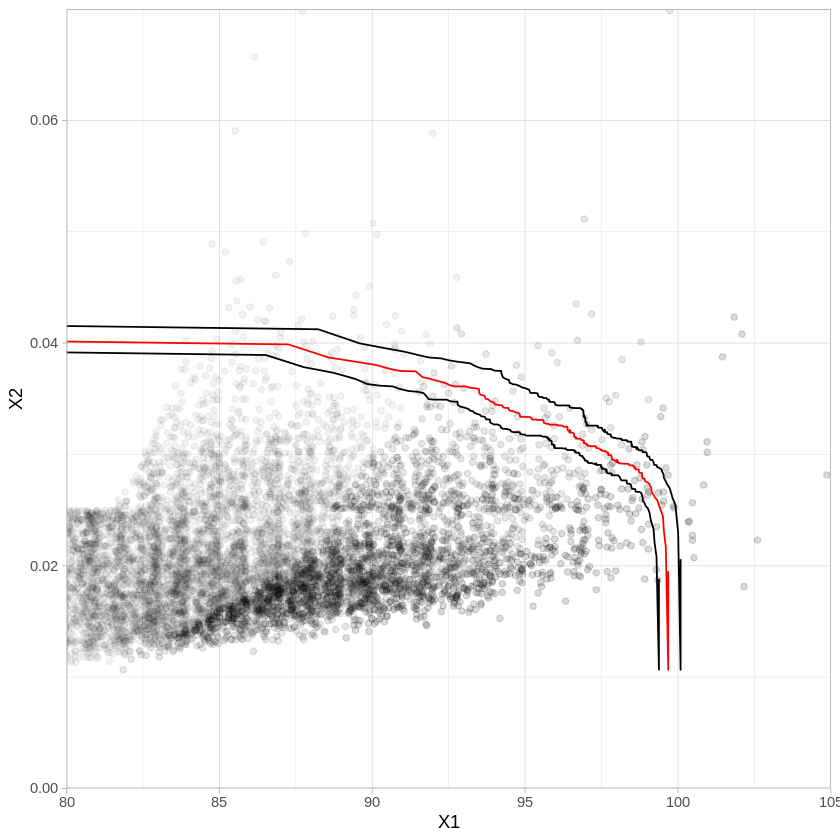

In [109]:
plt <- ggplot() + geom_point(data=dat, aes(x=X1, y=X2), alpha=0.05) + 
          geom_line(data=ext_lower, aes(x=X1, y=X2)) + 
           geom_line(data=ext_upper, aes(x=X1, y=X2)) +
           geom_line(data=best_estimate_original, aes(x=X1, y=X2), color='red') +
           coord_cartesian(xlim=c(80,105), ylim=c(0,.07), expand=0) +
           theme_light()

plt

In [71]:
write.table(ext_upper, file = "/global/cfs/cdirs/m3318/HadISD/v342_202508p/cities/Philadelphia/aridity_ext_upper_005.dat", sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)
write.table(ext_lower, file = "/global/cfs/cdirs/m3318/HadISD/v342_202508p/cities/Philadelphia/aridity_ext_lower_005.dat", sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

In [72]:
ext_upper_hurs <- data.frame(X1 = ext_upper$X1, X2 = 1 / ext_upper$X2 )
ext_lower_hurs <- data.frame(X1 = ext_upper$X1, X2 = 1 / ext_lower$X2 )
write.table(ext_upper_hurs, file = "/global/cfs/cdirs/m3318/HadISD/v342_202508p/cities/Philadelphia/hurs_ext_upper_005.dat", sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)
write.table(ext_lower_hurs, file = "/global/cfs/cdirs/m3318/HadISD/v342_202508p/cities/Philadelphia/hurs_ext_lower_005.dat", sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

In [12]:
# below this line are test things
gamma <- 1/2
extreme_tube1 <- computeExtremeRegion(dat=dat,
                                     alphas=c(0.1),
                                     p=0.005,
                                     B=500,
                                     gamma=gamma,
                                     xi=1,
                                     verbose=TRUE)


  |======================================================================| 100%


In [13]:
drawn_tubes1 <- drawExtremeTubes(extreme_tube1, alpha=0.1, lbs=c(0,0), n_coords=200)
ext_upper1 <- drawn_tubes1$tube_lower
ext_lower1 <- drawn_tubes1$tube_upper

In [14]:
head(ext_upper1)

,X1,X2
,<dbl>,<dbl>
1,99.38875,0.01066001
2,99.30981,0.02017217
3,99.24571,0.02241040
4,99.16504,0.02405506
5,99.07447,0.02503723
6,98.97225,0.02539916


In [15]:
head(ext_upper)

,X1,X2
,<dbl>,<dbl>
1,99.37543,0.01066001
2,99.29650,0.02013207
3,99.23241,0.02236504
4,99.15175,0.02401737
5,99.06120,0.02500779
6,98.95900,0.02536938
